# Lane and Road Boundary Detection under Weather and Occlusion

**Course:** Machine Learning (Summer 2026)  
**Group:** 05
**Project Title:**  Lane and Road Boundary Detection Under Weather and Occlusion
**Team members / matriculation numbers:** 
Niruta Chapagain - 39097867
Umesh Singh - 58326751
Ismail Demircan - 85110498
**Date:** 20 May 2026

> Presentation notebook: all reported values are generated by the executable cells below. No simulated loss, random metric, or claimed CNN is used.


## Problem statement

- Detect lane/road-boundary pixels in challenging CULane driving scenes.
- Compare two training-free image-processing baselines against one genuinely trained pixel classifier.
- Use official CULane train/validation/test lists; choose the model using validation only.
- Report pixel-level precision, recall, F1, IoU, and accuracy, then inspect failures by scenario.


In [1]:
import json, random, time
from datetime import datetime, timezone
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, precision_score, recall_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'CULane' / 'list').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from the project folder containing data/CULane.')

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / 'data' / 'CULane'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
OUTPUT_ROOT.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Dataset root:', DATA_ROOT)
print('Random seed:', SEED)


Project root: /Users/niruta/Documents/2nd Sem all materials/Machine Learning/Lane and Road Boundary Detection
Dataset root: /Users/niruta/Documents/2nd Sem all materials/Machine Learning/Lane and Road Boundary Detection/data/CULane
Random seed: 42


## Dataset review and reproducible subset

- Dataset: [CULane](https://xingangpan.github.io/projects/CULane.html), road images with lane annotations/segmentation masks.
- Labels: non-zero pixels in `laneseg_label_w16*` are lane pixels; zero is background.
- The full local dataset is large, so the trained model uses a deterministic, evenly spaced training subset. This keeps the live demonstration practical while preserving the official split.
- Some official-list images are absent locally; the code filters only missing files and prints the resulting counts.


In [2]:
def read_entries(list_file):
    entries = []
    for line in Path(list_file).read_text().splitlines():
        parts = line.split()
        if parts:
            entries.append({'image_rel': parts[0], 'mask_rel': parts[1] if len(parts) > 1 and parts[1].startswith('/') else None})
    return entries

def image_path(entry):
    return DATA_ROOT / entry['image_rel'].lstrip('/')

def mask_path(entry):
    if entry.get('mask_rel'):
        p = DATA_ROOT / entry['mask_rel'].lstrip('/')
        if p.is_file(): return p
    relative = Path(entry['image_rel'].lstrip('/')).with_suffix('.png')
    for root in ('laneseg_label_w16', 'laneseg_label_w16_test'):
        p = DATA_ROOT / root / relative
        if p.is_file(): return p
    return None

def available(entries, require_mask=False):
    return [e for e in entries if image_path(e).is_file() and (not require_mask or mask_path(e) is not None)]

def spaced(items, n):
    if len(items) <= n: return list(items)
    return [items[i] for i in np.linspace(0, len(items) - 1, n, dtype=int)]

splits = {name: read_entries(DATA_ROOT / 'list' / file) for name, file in
          {'train': 'train.txt', 'validation': 'val.txt', 'test': 'test.txt'}.items()}
split_summary = pd.DataFrame([
    {'split': name, 'official_list_entries': len(entries), 'local_images_with_masks': len(available(entries, True))}
    for name, entries in splits.items()
])
display(split_summary)


,split,official_list_entries,local_images_with_masks
0,train,88880,88542
1,validation,9675,9622
2,test,34680,16978


## Manual visual inspection

The following samples are real CULane images and segmentation labels. This verifies image/mask alignment before modelling.


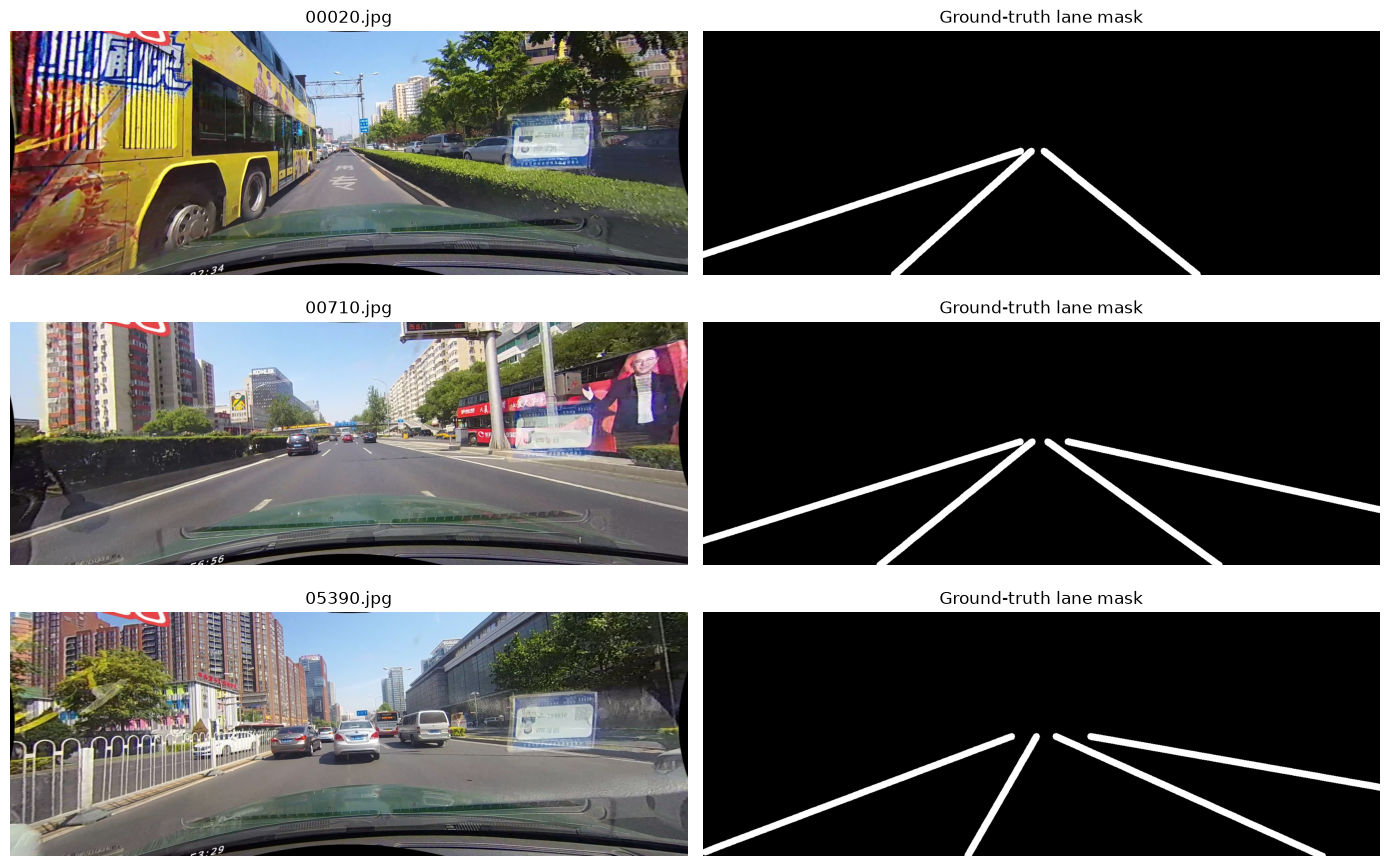

In [3]:
def load_image_and_mask(entry):
    image = np.asarray(Image.open(image_path(entry)).convert('RGB'))
    target = np.asarray(Image.open(mask_path(entry)).convert('L')) > 0
    return image, target

examples = spaced(available(splits['validation'], True), 3)
fig, axes = plt.subplots(len(examples), 2, figsize=(14, 3 * len(examples)))
for row, entry in enumerate(examples):
    image, target = load_image_and_mask(entry)
    axes[row, 0].imshow(image); axes[row, 0].set_title(Path(entry['image_rel']).name); axes[row, 0].axis('off')
    axes[row, 1].imshow(target, cmap='gray'); axes[row, 1].set_title('Ground-truth lane mask'); axes[row, 1].axis('off')
plt.tight_layout()


## Methodology

- **Split design:** official CULane lists; validation is used for comparison/model selection. Test scenario analysis is reported separately.
- **Preprocessing:** RGB pixels are scaled to [0, 1]; normalized x/y coordinates are added as features. Masks are binarized into lane/background.
- **Training subset:** deterministic evenly spaced images; per image, lane and background pixels are balanced to avoid a background-only model.
- **Evaluation:** all models use the same validation images and pixel masks. F1 and IoU are emphasized because lane pixels are rare.


## Selected models

1. **Colour threshold baseline** - detects bright white/yellow markings; fast but lighting-sensitive.
2. **Canny + Hough baseline** - detects geometric edges/line segments; no training required.
3. **Histogram Gradient Boosting pixel classifier** - a real supervised ML model trained below and saved as a `.joblib` file. It is **not a CNN**.


In [4]:
def pixel_features(image):
    rgb = image.astype(np.float32) / 255.0
    h, w = rgb.shape[:2]
    yy, xx = np.mgrid[:h, :w]
    return np.column_stack((rgb.reshape(-1, 3), xx.reshape(-1) / max(w - 1, 1), yy.reshape(-1) / max(h - 1, 1)))

def colour_baseline(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    white = (hsv[:, :, 2] > 180) & (hsv[:, :, 1] < 100)
    yellow = (hsv[:, :, 0] > 15) & (hsv[:, :, 0] < 40) & (hsv[:, :, 2] > 120)
    return cv2.medianBlur(((white | yellow).astype(np.uint8) * 255), 5) > 0

def hough_baseline(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 50, minLineLength=40, maxLineGap=50)
    result = np.zeros_like(gray)
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]: cv2.line(result, (x1, y1), (x2, y2), 255, 3)
    return result > 0

def build_training_data(entries, images_to_use=32, pixels_per_image=3500):
    rng = np.random.default_rng(SEED)
    x_parts, y_parts = [], []
    for entry in spaced(entries, images_to_use):
        image, target = load_image_and_mask(entry)
        y = target.reshape(-1).astype(np.uint8)
        pos, neg = np.flatnonzero(y == 1), np.flatnonzero(y == 0)
        if not len(pos) or not len(neg): continue
        n_pos = min(len(pos), pixels_per_image // 2)
        chosen = np.concatenate((rng.choice(pos, n_pos, replace=False), rng.choice(neg, pixels_per_image - n_pos, replace=False)))
        rng.shuffle(chosen)
        x_parts.append(pixel_features(image)[chosen]); y_parts.append(y[chosen])
    return np.vstack(x_parts), np.concatenate(y_parts)


## Genuine model training and timing log

The next cell performs actual `fit(...)` training. It records UTC start/end timestamps, elapsed time, training-image count, and sampled pixels, then saves the fitted model for a presentation backup.


In [5]:
train_entries = available(splits['train'], True)
training_started_at = datetime.now(timezone.utc)
timer = time.perf_counter()
X_train, y_train = build_training_data(train_entries)
model = HistGradientBoostingClassifier(learning_rate=0.08, max_depth=6, max_iter=80, min_samples_leaf=25, early_stopping=True, random_state=SEED)
model.fit(X_train, y_train)
training_ended_at = datetime.now(timezone.utc)
elapsed_seconds = time.perf_counter() - timer

model_path = OUTPUT_ROOT / 'culane_pixel_classifier.joblib'
joblib.dump(model, model_path)
run_log = pd.DataFrame([{
    'started_utc': training_started_at.isoformat(), 'ended_utc': training_ended_at.isoformat(),
    'elapsed_seconds': round(elapsed_seconds, 2), 'train_images_available': len(train_entries),
    'training_images_used': 32, 'sampled_pixels': len(y_train), 'seed': SEED, 'model_file': str(model_path.relative_to(PROJECT_ROOT))
}])
run_log.to_csv(OUTPUT_ROOT / 'training_run_log.csv', index=False)
display(run_log)
print(f'Model fitted and saved: {model_path} ({model_path.stat().st_size / 1024:.1f} KB)')


,started_utc,ended_utc,elapsed_seconds,train_images_available,training_images_used,sampled_pixels,seed,model_file
0,2026-06-22T07:34:56.232242+00:00,2026-06-22T07:34:56.997505+00:00,0.77,88542,32,105000,42,outputs/culane_pixel_classifier.joblib


Model fitted and saved: /Users/niruta/Documents/2nd Sem all materials/Machine Learning/Lane and Road Boundary Detection/outputs/culane_pixel_classifier.joblib (283.6 KB)


## Evaluation criterion

- **Precision:** of predicted lane pixels, how many are correct?
- **Recall:** of true lane pixels, how many are found?
- **F1:** balances precision and recall for the sparse lane class.
- **IoU:** overlap quality of the predicted and true lane regions.
- **Accuracy:** included for completeness but can be inflated by dominant background pixels.


In [6]:
def predict_ml(image):
    return model.predict(pixel_features(image)).reshape(image.shape[:2]).astype(bool)

def score_prediction(prediction, target):
    y_true, y_pred = target.reshape(-1), prediction.reshape(-1)
    return {
        'accuracy': accuracy_score(y_true, y_pred), 'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0), 'f1': f1_score(y_true, y_pred, zero_division=0),
        'iou': jaccard_score(y_true, y_pred, zero_division=0)}

PREDICTORS = {'Colour threshold': colour_baseline, 'Canny + Hough': hough_baseline, 'Trained pixel classifier': predict_ml}

def evaluate(entries, max_images=20):
    rows = []
    for entry in spaced(entries, max_images):
        image, target = load_image_and_mask(entry)
        for name, predictor in PREDICTORS.items(): rows.append({'model': name, 'image': entry['image_rel'], **score_prediction(predictor(image), target)})
    return pd.DataFrame(rows)

validation_records = evaluate(available(splits['validation'], True), max_images=20)
validation_summary = validation_records.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'iou']].mean().sort_values('f1', ascending=False)
display(validation_summary.round(4))


,accuracy,precision,recall,f1,iou
model,,,,,
Trained pixel classifier,0.6524,0.0893,0.8875,0.1616,0.0886
Canny + Hough,0.4781,0.0384,0.4877,0.0707,0.0370
Colour threshold,0.7146,0.0304,0.2122,0.0527,0.0273


## Error analysis by CULane scenario

The scenario table uses locally available, labelled images from the official test-category files. These are an analysis set, not the basis for model selection.


In [7]:
scenario_rows = []
for file in sorted((DATA_ROOT / 'list' / 'test_split').glob('test*.txt')):
    category = file.stem.split('_', 1)[1]
    entries = available([{'image_rel': line.split()[0], 'mask_rel': None} for line in file.read_text().splitlines() if line.strip()], True)
    if entries:
        # One deterministic labelled sample per official scenario keeps the
        # live presentation demonstration responsive; validation remains the
        # 20-image model-comparison set above.
        scored = evaluate(entries, max_images=1)
        scored['scenario'] = category
        scenario_rows.append(scored)
scenario_records = pd.concat(scenario_rows, ignore_index=True)
scenario_summary = scenario_records.groupby(['scenario', 'model'])[['f1', 'iou', 'recall']].mean().reset_index()
display(scenario_summary.pivot(index='scenario', columns='model', values='f1').round(4))


model,Canny + Hough,Colour threshold,Trained pixel classifier
scenario,,,
arrow,0.0340,0.0145,0.1317
cross,0.0000,0.0000,0.0000
crowd,0.0520,0.0503,0.1911
curve,0.0716,0.0085,0.1258
hlight,0.0673,0.0612,0.2086
night,0.0777,0.0334,0.2042
noline,0.0469,0.0892,0.1499
normal,0.0466,0.0145,0.1474
shadow,0.0435,0.0002,0.1264


## Qualitative results and failure cases

Predictions below are generated by the trained model and baselines in this notebook. Typical errors include glare/shadows producing false edges, parked vehicles occluding markings, and worn/no-line scenes reducing recall.


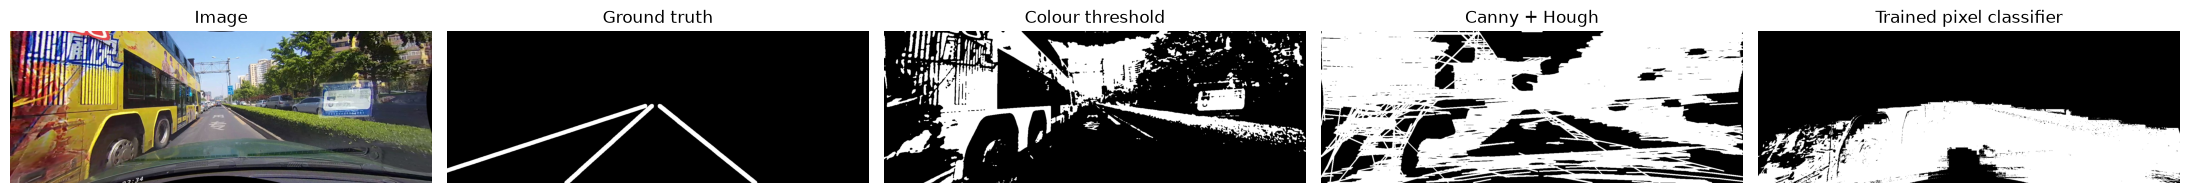

In [8]:
entry = spaced(available(splits['validation'], True), 1)[0]
image, target = load_image_and_mask(entry)
visuals = [('Image', image), ('Ground truth', target), *[(name, predictor(image)) for name, predictor in PREDICTORS.items()]]
fig, axes = plt.subplots(1, len(visuals), figsize=(22, 5))
for ax, (title, visual) in zip(axes, visuals):
    ax.imshow(visual, cmap='gray' if np.ndim(visual) == 2 else None); ax.set_title(title); ax.axis('off')
plt.tight_layout()


In [9]:
best_model = validation_summary.index[0]
best_f1 = validation_summary.iloc[0]['f1']
print('Conclusion')
print(f'- On the deterministic validation subset, the best F1 was {best_f1:.4f} from: {best_model}.')
print('- This is a lightweight pixel classifier, not a CNN; its saved model and timing log make the demonstration reproducible.')
print('- Limitations: the model uses a small subset, independent pixels (no temporal context), and pixel-mask metrics rather than official CULane lane-instance evaluation.')
print('- Next steps: train a true segmentation network, use the official CULane evaluator, and add temporal/video consistency.')


Conclusion
- On the deterministic validation subset, the best F1 was 0.1616 from: Trained pixel classifier.
- This is a lightweight pixel classifier, not a CNN; its saved model and timing log make the demonstration reproducible.
- Limitations: the model uses a small subset, independent pixels (no temporal context), and pixel-mask metrics rather than official CULane lane-instance evaluation.
- Next steps: train a true segmentation network, use the official CULane evaluator, and add temporal/video consistency.


## Presentation checklist

- Run **Kernel -> Restart Kernel and Run All Cells** once before presenting.
- Confirm `outputs/culane_pixel_classifier.joblib` and `outputs/training_run_log.csv` were created.
- Keep this notebook and the `data/CULane` folder locally; the dataset is intentionally not committed to Git because of its size.
- Team should be ready to explain the subset, pixel-level metrics, official split, and limitations.
